# Отток клиентов телеком-компании

**Цель проекта:**
- найти, какие клиенты уходят чаще и почему;
- построить модель, которая по данным клиента предсказывает вероятность ухода.

**Данные**: Telco Customer Churn

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score
from sklearn.inspection import permutation_importance

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

ORANGE = '#eb6834'
BLUE = '#2a78d6'

## 1. Данные

In [28]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Пустых TotalCharges:', df['TotalCharges'].isna().sum())
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Пустых TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Это 11 клиентов с tenure = 0: они только подключились и ещё ничего не заплатили. Ставлю 0.

In [32]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns='customerID')

print('Дубликатов:', df.duplicated().sum())
print('Пропусков:', df.isna().sum().sum())

Дубликатов: 22
Пропусков: 0


## 2. Анализ оттока

In [34]:
churn_share = df['Churn'].value_counts(normalize=True) * 100
print(churn_share.round(1))

avg_churn = df['Churn'].mean() * 100

Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


Уходит 26.5% клиентов.

In [36]:
def plot_churn(column, title):
    churn_rate = df.groupby(column)['Churn'].mean().sort_values() * 100

    ax = churn_rate.plot(kind='barh', color=ORANGE)
    ax.bar_label(ax.containers[0], fmt='%.0f%%', padding=3)
    plt.axvline(avg_churn, color='gray', linestyle='--')
    plt.title(title)
    plt.xlabel('Отток, %')
    plt.ylabel('')
    plt.show()

### Когда уходят клиенты?

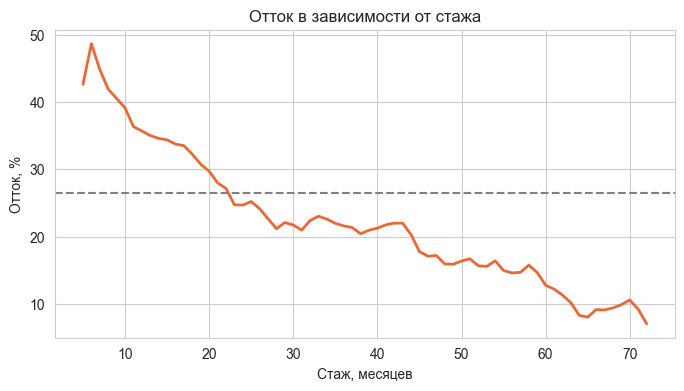

In [38]:
churn_by_tenure = df.groupby('tenure')['Churn'].mean() * 100

churn_by_tenure.rolling(6).mean().plot(color=ORANGE, linewidth=2)
plt.axhline(avg_churn, color='gray', linestyle='--')
plt.title('Отток в зависимости от стажа')
plt.xlabel('Стаж, месяцев')
plt.ylabel('Отток, %')
plt.show()

Больше всего уходят в первые месяцы, потом отток быстро падает. Клиенты, которые остались на 5+ лет, почти не уходят.

### Тип контракта

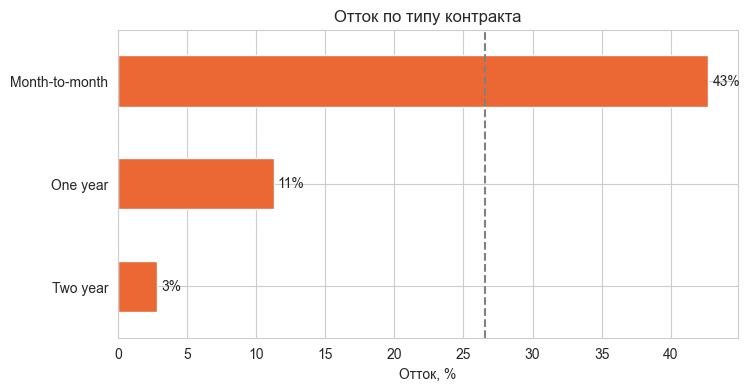

In [41]:
plot_churn('Contract', 'Отток по типу контракта')

Помесячный контракт: 43%, двухлетний: 3%. Это самый сильный фактор.

### Ежемесячный платёж

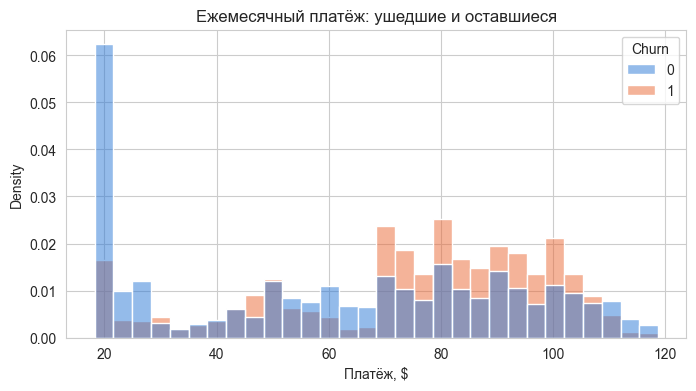

In [44]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', stat='density', common_norm=False,
             palette=[BLUE, ORANGE], bins=30)
plt.title('Ежемесячный платёж: ушедшие и оставшиеся')
plt.xlabel('Платёж, $')
plt.show()

Ушедшие чаще платят 70–105.  
У клиентов с дешёвыми тарифами (около 20 $) отток низкий.

### Услуги и оплата

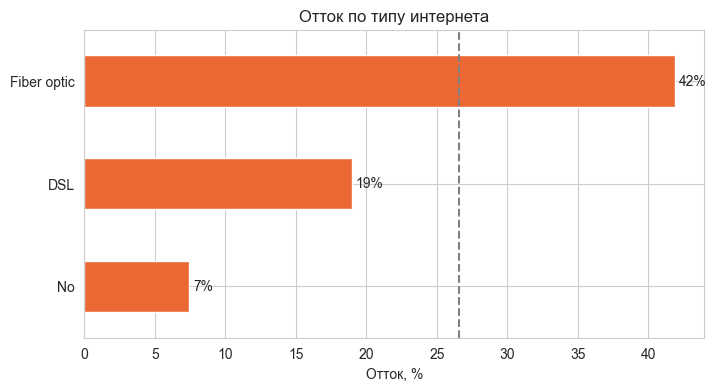

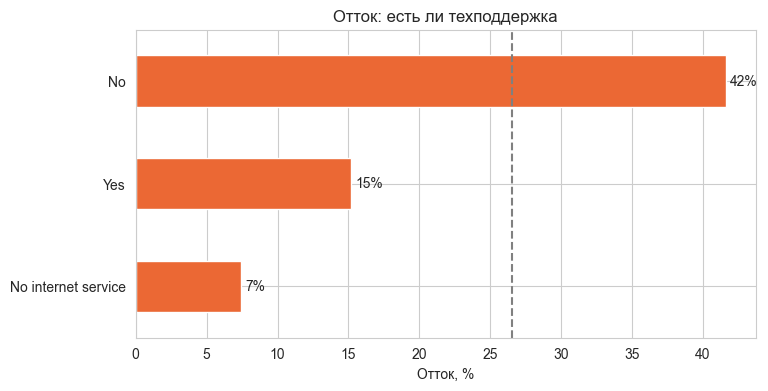

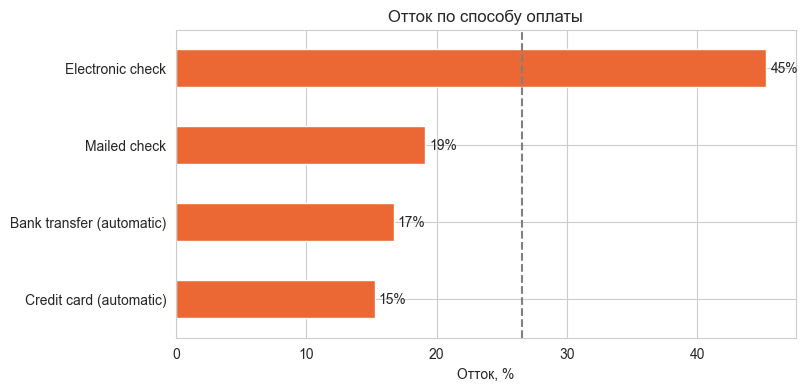

In [47]:
plot_churn('InternetService', 'Отток по типу интернета')
plot_churn('TechSupport', 'Отток: есть ли техподдержка')
plot_churn('PaymentMethod', 'Отток по способу оплаты')

- Оптоволокно — 42% оттока, в 2 раза больше, чем DSL. 
- Без техподдержки уходят 42%, с ней — 15%.
- Electronic check — 45%. При автоплатеже (банк, карта) уходят 15–17%.

### Демография

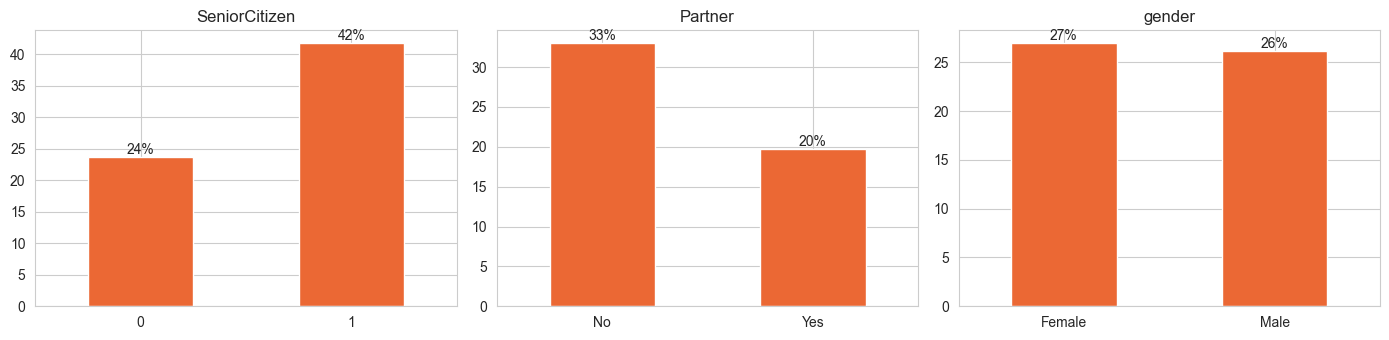

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, column in zip(axes, ['SeniorCitizen', 'Partner', 'gender']):
    churn_rate = df.groupby(column)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color=ORANGE, rot=0)
    ax.bar_label(ax.containers[0], fmt='%.0f%%')
    ax.set_title(column)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Пенсионеры и клиенты без партнёра уходят чаще. Пол на отток не влияет.

### Контракт и интернет

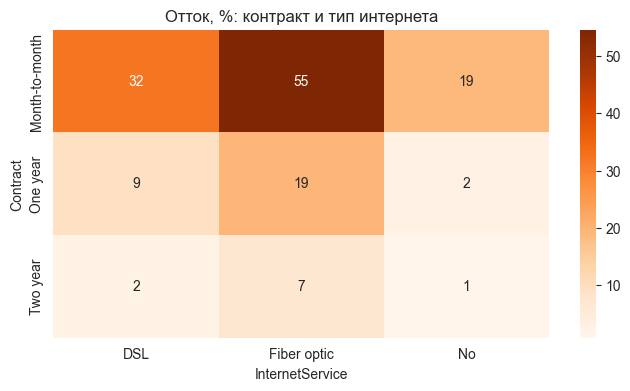

In [53]:
pivot = df.pivot_table(index='Contract', columns='InternetService', values='Churn') * 100

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Oranges')
plt.title('Отток, %: контракт и тип интернета')
plt.show()

Помесячный контракт + оптоволокно: уходит 55%. Это главная группа риска, в ней 30% всех клиентов.

**Итог анализа.** Чаще всего уходят новые клиенты на помесячном контракте, с оптоволокном, без техподдержки и с оплатой electronic check.

## 3. Подготовка признаков

In [56]:
data = df.copy()
data = data.replace({'No internet service': 'No', 'No phone service': 'No'})
data['is_new_client'] = (data['tenure'] <= 12).astype(int)
data['auto_payment'] = data['PaymentMethod'].str.contains('automatic').astype(int)
data['monthly_fiber'] = ((data['Contract'] == 'Month-to-month') &
                         (data['InternetService'] == 'Fiber optic')).astype(int)

In [57]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                  'StreamingMovies', 'PaperlessBilling']

for column in yes_no_columns:
    data[column] = data[column].map({'Yes': 1, 'No': 0})

data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

data = pd.get_dummies(data, columns=['InternetService', 'Contract', 'PaymentMethod'],
                      drop_first=True, dtype=int)
print(data.shape)

(7043, 27)


In [58]:
X = data.drop(columns='Churn')
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(5634, 26) (1409, 26)


## 4. Модели

Сравниваю три модели на кросс-валидации. 
Главные метрики:
recall — какую долю уходящих клиентов модель находит;
ROC-AUC — общее качество модели.

In [60]:
models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight='balanced', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=5,
                            scoring=['recall', 'precision', 'f1', 'roc_auc'])
    results.append({
        'model': name,
        'recall': scores['test_recall'].mean(),
        'precision': scores['test_precision'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean(),
    })

pd.DataFrame(results).set_index('model').round(3)

,recall,precision,f1,roc_auc
model,,,,
Logistic Regression,0.800,0.519,0.630,0.846
Random Forest,0.748,0.559,0.639,0.846
Gradient Boosting,0.524,0.660,0.584,0.846


ROC-AUC у всех моделей около 0.84–0.85. У Gradient Boosting нет `class_weight`, поэтому его recall низкий: он пропускает почти половину уходящих.

Выбираю логистическую регрессию: качество такое же, как у Random Forest, а модель проще.

## 5. Проверка на тестовых данных

In [63]:
model = models['Logistic Regression']
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=['Остался', 'Ушёл']))

ROC-AUC: 0.841
              precision    recall  f1-score   support

     Остался       0.91      0.71      0.80      1035
        Ушёл       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409



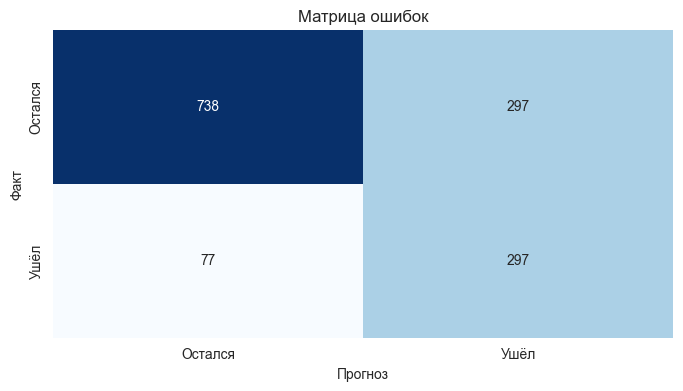

In [64]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Остался', 'Ушёл'], yticklabels=['Остался', 'Ушёл'])
plt.xlabel('Прогноз')
plt.ylabel('Факт')
plt.title('Матрица ошибок')
plt.show()

Модель находит около 80% уходящих клиентов. Обратная сторона: примерно половина клиентов, отмеченных как «уйдёт», на самом деле остаётся. Для удержания это нормально: позвонить или дать скидку лишнему клиенту дешевле, чем потерять клиента.

Порог можно менять под задачу бизнеса:

In [66]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_proba >= threshold).astype(int)
    print(f'порог {threshold}:  recall = {recall_score(y_test, pred):.2f}, '
          f'precision = {precision_score(y_test, pred):.2f}')

порог 0.3:  recall = 0.93, precision = 0.43
порог 0.4:  recall = 0.86, precision = 0.47
порог 0.5:  recall = 0.79, precision = 0.50
порог 0.6:  recall = 0.71, precision = 0.55
порог 0.7:  recall = 0.58, precision = 0.61


Ниже порог — больше пойманных уходящих, но больше лишних звонков.

## 6. Какие признаки важны для модели

Перемешиваю каждый признак по очереди и смотрю, насколько падает ROC-AUC. Чем сильнее падение, тем важнее признак.

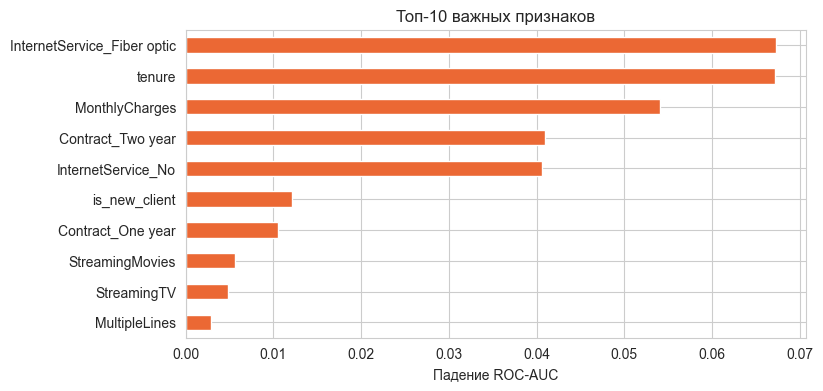

In [69]:
result = permutation_importance(model, X_test, y_test, scoring='roc_auc',
                                n_repeats=10, random_state=42)

importance = pd.Series(result.importances_mean, index=X_test.columns)
importance.sort_values().tail(10).plot(kind='barh', color=ORANGE)
plt.title('Топ-10 важных признаков')
plt.xlabel('Падение ROC-AUC')
plt.show()

Самые важные признаки — оптоволокно, стаж, ежемесячный платёж и тип контракта. Это совпадает с тем, что показал анализ.

## 7. Польза для бизнеса

Если обзванивать клиентов с самым высоким риском, сколько уходящих мы поймаем?

In [72]:
test = pd.DataFrame({'churn': y_test.values, 'proba': y_proba})
test = test.sort_values('proba', ascending=False)

for share in [0.1, 0.2, 0.3]:
    top = test.head(int(len(test) * share))
    caught = top['churn'].sum() / test['churn'].sum() * 100
    print(f'обзвон топ-{int(share * 100)}% клиентов: находим {caught:.0f}% уходящих')

обзвон топ-10% клиентов: находим 28% уходящих
обзвон топ-20% клиентов: находим 49% уходящих
обзвон топ-30% клиентов: находим 66% уходящих


Обзвон 20% клиентов из топа риска находит около половины всех уходящих. При случайном обзвоне было бы 20%.

## Выводы

- Уходит 26.5% клиентов, чаще всего в первый год.
- Главные факторы: помесячный контракт, оптоволокно, оплата electronic check, отсутствие техподдержки.
- Логистическая регрессия: ROC-AUC 0.84, находит ~80% уходящих.

**Рекомендации:**
1. Предлагать скидку за переход на годовой контракт, в первую очередь клиентам с оптоволокном.
2. Больше внимания новым клиентам в первые 12 месяцев.
3. Давать бонус за подключение автоплатежа.
4. Проверить цену и качество оптоволокна.
5. Каждую неделю передавать отделу удержания список клиентов с высоким риском.